# Baseline ML-Propensity Models - Classification Approach
---

## Main imports
---

In [0]:
%pip install -q xgboost lightgbm shap optuna

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.tree import plot_tree, export_text
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix
)
import shap
import optuna

## Data reading
---

In [0]:
path = "workspace.personal_playground.ecommerce_data_cleaned"
df   = spark.table(path).toPandas()

In [0]:
df.head()

,customer_id,age,subscription_type,tenure_months,monthly_charges,total_sessions,support_tickets,last_login_days,referral_bonus_used,churn,expected_ltv,gender_M,gender_Other,region_North,region_South,region_West,device_type_Mobile,device_type_Tablet
0,1,0.422560,1.0,0.880503,1.667029,-0.398513,-1.158004,1.672489,1,0,1811.230169,1,0,0,1,0,0,0
1,2,1.156881,2.0,-1.659555,-1.284442,0.266831,1.618682,0.287269,1,1,428.055423,1,0,0,1,0,0,1
2,3,-0.142303,0.0,0.733961,0.404791,-1.445045,0.924510,-0.520776,1,1,1149.288576,0,0,0,0,1,0,1
3,4,-0.933111,2.0,0.147794,0.949968,0.654949,0.924510,-0.636211,0,1,1625.440249,1,0,1,0,0,0,1
4,5,0.000192,1.0,1.417823,1.157023,1.458907,-1.158004,0.171834,1,0,1837.842564,1,0,0,0,0,0,1


## XGBoost
---

In [0]:
def fit_xgb_churn_pipeline(
    df: pd.DataFrame,
    target_col: str = 'churn',
    id_col: str = 'customer_id',
    test_size: float = 0.20,
    threshold_fs: str = 'median',
    n_iter_search: int = 15,
    cv_splits: int = 5,
    random_state: int = 42
) -> dict:
    
    cols_to_drop = [target_col]
    if id_col in df.columns:
        cols_to_drop.append(id_col)
    
    X = df.drop(columns=cols_to_drop)
    y = df[target_col]

    # STRATIFIED TRAIN/TEST SPLIT
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )
    

    print(" 1. DATASET INFORMATION AND IMBALANCE RATIO")
    print("=" * 60)
    print(f"- Train set: {X_train.shape[0]} records | {X_train.shape[1]} features")
    print(f"- Test set:  {X_test.shape[0]} records | {X_test.shape[1]} features")

    num_neg = (y_train == 0).sum()
    num_pos = (y_train == 1).sum()
    scale_pos_weight = num_neg / num_pos if num_pos > 0 else 1.0
    print(f"- Calculated scale_pos_weight ratio: {scale_pos_weight:.3f}")

    # MODEL PIPELINE 
    xgb_base = xgb.XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        eval_metric='aucpr',
        n_jobs=-1
    )

    selector = SelectFromModel(
        estimator=xgb_base,
        threshold=threshold_fs,
        importance_getter='feature_importances_'
    )

    pipeline = Pipeline([
        ('feature_selection', selector),
        ('xgb', xgb_base)
    ])

    # HYPERPARAMETER TUNING WITH OPTUNA
    print("\n")
    print(" 2. OPTIMIZATION AND CROSS-VALIDATION (OPTUNA)")
    print("=" * 60)
    
    # CROSS VALIDATION STRATEGY
    cv_strategy = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    
    # OPTUNA OBJECTIVE FUNCTION
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_categorical('n_estimators', [100, 200, 300]),
            'max_depth': trial.suggest_categorical('max_depth', [3, 5, 7, 9]),
            'learning_rate': trial.suggest_categorical('learning_rate', [0.01, 0.05, 0.1, 0.2]),
            'subsample': trial.suggest_categorical('subsample', [0.6, 0.8, 1.0]),
            'colsample_bytree': trial.suggest_categorical('colsample_bytree', [0.6, 0.8, 1.0]),
            'min_child_weight': trial.suggest_categorical('min_child_weight', [1, 3, 5]),
            'gamma': trial.suggest_categorical('gamma', [0, 0.1, 0.2])
        }
        
        # CREATE MODEL
        model = xgb.XGBClassifier(
            objective='binary:logistic',
            scale_pos_weight=scale_pos_weight,
            random_state=random_state,
            eval_metric='aucpr',
            n_jobs=-1,
            **params
        )
        
        # CREATE PIPELINE WITH FEATURE SELECTION
        selector = SelectFromModel(
            estimator=model,
            threshold=threshold_fs,
            importance_getter='feature_importances_'
        )
        
        trial_pipeline = Pipeline([
            ('feature_selection', selector),
            ('xgb', model)
        ])
        
        # MANUAL CV LOOP FOR PRUNING
        cv_scores = []
        for fold_idx, (train_idx, val_idx) in enumerate(cv_strategy.split(X_train, y_train)):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            trial_pipeline.fit(X_fold_train, y_fold_train)
            fold_score = f1_score(y_fold_val, trial_pipeline.predict(X_fold_val), zero_division=0)
            cv_scores.append(fold_score)
            
            trial.report(np.mean(cv_scores), fold_idx)
            
            if trial.should_prune():
                raise optuna.TrialPruned()
        
        return np.mean(cv_scores)
    
    # CREATE OPTUNA STUDY AND OPTIMIZE
    sampler = optuna.samplers.TPESampler(seed=random_state)
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=2
    )
    
    study = optuna.create_study(
        direction='maximize',
        sampler=sampler,
        pruner=pruner,
        study_name='xgboost_propensity_optimization'
    )
    
    study.optimize(objective, n_trials=n_iter_search, show_progress_bar=True)
    
    # EXTRACT BEST HYPERPARAMETERS
    best_params = study.best_params
    cv_f1_mean = study.best_value
    best_trial = study.best_trial
    cv_f1_std = 0.0
    
    # PRUNING STATISTICS
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruned_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
    
    print("\n--- Cross-Validation Results (F1-Score Metric) ---")
    print(f" - Best CV F1-Score: {cv_f1_mean:.4f}")
    print(f" - Best Trial Number: {best_trial.number}")
    print(f" - Total Trials Started: {len(study.trials)}")
    print(f" - Trials Completed: {len(completed_trials)}")
    print(f" - Trials Pruned (Early Stopping): {len(pruned_trials)}")
    if len(pruned_trials) > 0:
        print(f" - Time Saved by Pruning: ~{len(pruned_trials) * 10}s (estimated)")
    
    print("\n--- Optimal Hyperparameters Found ---")
    cleaned_params = best_params.copy()
    for param, value in cleaned_params.items():
        print(f" - {param}: {value}")
    
    # TRAIN FINAL MODEL WITH BEST HYPERPARAMETERS
    best_model = xgb.XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        eval_metric='aucpr',
        n_jobs=-1,
        **best_params
    )
    
    best_selector = SelectFromModel(
        estimator=best_model,
        threshold=threshold_fs,
        importance_getter='feature_importances_'
    )
    
    best_pipeline = Pipeline([
        ('feature_selection', best_selector),
        ('xgb', best_model)
    ])
    
    best_pipeline.fit(X_train, y_train)
    best_model = best_pipeline.named_steps['xgb']
    best_selector = best_pipeline.named_steps['feature_selection']

    # FEATURE SELECTION REPORTING
    selected_mask = best_selector.get_support()
    selected_features = X.columns[selected_mask].tolist()
    removed_features = X.columns[~selected_mask].tolist()

    print("\n")
    print(" 3. FEATURE SELECTION")
    print("=" * 60)
    print(f" - Initial Predictor Features: {X.shape[1]}")
    print(f" - Selected Features:          {len(selected_features)}")
    print(f" - Discarded Features:         {len(removed_features)}")

    print("\n--- Kept Features List ---")
    for feat in selected_features:
        print(f"   - {feat}")

    print("\n--- Discarded Features List ---")
    for feat in removed_features:
        print(f"   - {feat}")

    # TRANSFORMATION
    X_train_sel = pd.DataFrame(best_selector.transform(X_train), columns=selected_features, index=X_train.index)
    X_test_sel = pd.DataFrame(best_selector.transform(X_test), columns=selected_features, index=X_test.index)

    # PROBABILITIES AND OPTIMAL THRESHOLD
    probs_train = best_model.predict_proba(X_train_sel)[:, 1]
    probs_test = best_model.predict_proba(X_test_sel)[:, 1]

    precisions_tr, recalls_tr, thresholds_tr = precision_recall_curve(y_train, probs_train)
    f1_scores_tr = (2 * precisions_tr * recalls_tr) / (precisions_tr + recalls_tr + 1e-8)
    best_idx = np.argmax(f1_scores_tr)
    best_threshold = thresholds_tr[best_idx] if best_idx < len(thresholds_tr) else 0.5

    print("\n")
    print(" 4. EVALUATION AND OPTIMAL THRESHOLD")
    print("=" * 60)
    print(f"- Optimal Threshold for F1-Score: {best_threshold:.4f}")

    preds_train_opt = (probs_train >= best_threshold).astype(int)
    preds_test_opt = (probs_test >= best_threshold).astype(int)

    # OUTPUT DATAFRAMES
    pred_prob_col = f'{target_col}_pred_prob'
    pred_label_col = f'{target_col}_pred_label_optimal'
    
    df_train_out = df.loc[X_train.index].copy()
    df_train_out[pred_prob_col] = probs_train
    df_train_out[pred_label_col] = preds_train_opt

    df_test_out = df.loc[X_test.index].copy()
    df_test_out[pred_prob_col] = probs_test
    df_test_out[pred_label_col] = preds_test_opt

    front_cols = [col for col in [id_col, target_col, pred_prob_col, pred_label_col] if col in df_train_out.columns]
    other_cols = [col for col in df_train_out.columns if col not in front_cols]
    
    df_train_out = df_train_out[front_cols + other_cols]
    df_test_out = df_test_out[front_cols + other_cols]

    # TRAIN/TEST METRICS
    def calculate_metrics(y_true, probs, preds, dataset_name):
        return {
            'Dataset': dataset_name,
            'Accuracy': accuracy_score(y_true, preds),
            'Precision': precision_score(y_true, preds, zero_division=0),
            'Recall': recall_score(y_true, preds, zero_division=0),
            'F1-Score (Opt)': f1_score(y_true, preds, zero_division=0),
            'AUC-ROC': roc_auc_score(y_true, probs),
            'AU-PR': average_precision_score(y_true, probs)
        }

    metrics_df = pd.DataFrame([
        calculate_metrics(y_train, probs_train, preds_train_opt, 'Train'),
        calculate_metrics(y_test, probs_test, preds_test_opt, 'Test')
    ]).set_index('Dataset')

    print("\n--- Final Performance Summary ---")
    print(metrics_df.round(4))

    # VISUALIZATIONS: ROC, PR CURVES AND CONFUSION MATRIX
    fig_eval, axes_eval = plt.subplots(1, 3, figsize=(18, 5))

    # ROC CURVE
    fpr, tpr, _ = roc_curve(y_test, probs_test)
    auc_roc = roc_auc_score(y_test, probs_test)
    
    axes_eval[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_roc:.4f})')
    axes_eval[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    axes_eval[0].set_xlim([0.0, 1.0])
    axes_eval[0].set_ylim([0.0, 1.05])
    axes_eval[0].set_xlabel('False Positive Rate')
    axes_eval[0].set_ylabel('True Positive Rate')
    axes_eval[0].set_title('ROC Curve - Propensity Model (Test Set)', fontsize=12, fontweight='bold')
    axes_eval[0].legend(loc="lower right")
    axes_eval[0].grid(True, linestyle='--', alpha=0.6)

    # PRECISION-RECALL CURVE
    prec_test, rec_test, _ = precision_recall_curve(y_test, probs_test)
    au_pr = average_precision_score(y_test, probs_test)
    
    axes_eval[1].plot(rec_test, prec_test, color='blue', lw=2, label=f'PR (AU-PR = {au_pr:.4f})')
    prec_opt = precision_score(y_test, preds_test_opt, zero_division=0)
    rec_opt = recall_score(y_test, preds_test_opt, zero_division=0)
    axes_eval[1].plot(rec_opt, prec_opt, 'ro', markersize=8, label=f'Threshold ({best_threshold:.3f})')
    
    axes_eval[1].set_xlim([0.0, 1.0])
    axes_eval[1].set_ylim([0.0, 1.05])
    axes_eval[1].set_xlabel('Recall (Sensitivity)')
    axes_eval[1].set_ylabel('Precision')
    axes_eval[1].set_title('Precision-Recall Curve - Propensity Model (Test Set)', fontsize=12, fontweight='bold')
    axes_eval[1].legend(loc="lower left")
    axes_eval[1].grid(True, linestyle='--', alpha=0.6)

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, preds_test_opt)
    cm_norm = confusion_matrix(y_test, preds_test_opt, normalize='true')
    
    labels = np.array([[f"{val:,}\n({norm:.1%})" for val, norm in zip(row_cm, row_norm)]
                       for row_cm, row_norm in zip(cm, cm_norm)])

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=axes_eval[2],
                xticklabels=['No Propensity (0)', 'Propensity (1)'],
                yticklabels=['No Propensity (0)', 'Propensity (1)'])
    axes_eval[2].set_xlabel('Model Prediction')
    axes_eval[2].set_ylabel('True Value')
    axes_eval[2].set_title(f'Confusion Matrix - Propensity Model (Test Set)\nThreshold: {best_threshold:.4f}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('evaluation_metrics_summary.png', dpi=150)
    plt.show()

    # FEATURE IMPORTANCE VISUALIZATIONS (WEIGHT AND GAIN)
    booster = best_model.get_booster()
    booster.feature_names = selected_features

    weight_imp = pd.Series(booster.get_score(importance_type='weight'), name='Weight')
    gain_imp = pd.Series(booster.get_score(importance_type='gain'), name='Gain')

    feat_imp = pd.DataFrame({'Weight': weight_imp, 'Gain': gain_imp}).fillna(0)
    feat_imp.index.name = 'Feature'

    fig_imp, axes_imp = plt.subplots(1, 2, figsize=(14, 5))
    feat_imp.sort_values(by='Weight', ascending=True)['Weight'].tail(15).plot(
        kind='barh', ax=axes_imp[0], color='skyblue'
    )
    axes_imp[0].set_title('Feature Relevance (Weight / Freq)')
    axes_imp[0].set_xlabel('Split Frequency')

    feat_imp.sort_values(by='Gain', ascending=True)['Gain'].tail(15).plot(
        kind='barh', ax=axes_imp[1], color='salmon'
    )
    axes_imp[1].set_title('Information Gain')
    axes_imp[1].set_xlabel('Mean Gain')
    plt.tight_layout()
    plt.savefig('xgb_native_feature_importance.png', dpi=150)
    plt.show()

    # 9. SHAP VISUALIZATIONS
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer(X_test_sel)

    plt.figure(figsize=(10, 6))
    plt.title('SHAP Summary Plot (Selected Features)', fontsize=12)
    shap.plots.beeswarm(shap_values, show=False)
    plt.tight_layout()
    plt.savefig('shap_summary_plot.png', dpi=150)
    plt.show()
    
    print("\n")
    plt.figure(figsize=(10, 6))
    plt.title('SHAP Feature Importance (Bar Plot)', fontsize=12)
    shap.plots.bar(shap_values, show=False)
    plt.tight_layout()
    plt.savefig('shap_bar_importance.png', dpi=150)
    plt.show()

    return {
        'best_pipeline': best_pipeline,
        'best_model': best_model,
        'best_params': cleaned_params,
        'cv_f1_score_mean': cv_f1_mean,
        'cv_f1_score_std': cv_f1_std,
        'optuna_study': study,
        'selected_features': selected_features,
        'removed_features': removed_features,
        'optimal_threshold': best_threshold,
        'metrics': metrics_df,
        'df_train_results': df_train_out,
        'df_test_results': df_test_out,
        'feature_importance': feat_imp,
        'shap_values': shap_values,
        'explainer': explainer
    }

[I 2026-08-11 06:59:20,825] A new study created in memory with name: xgboost_propensity_optimization


 1. DATASET INFORMATION AND IMBALANCE RATIO
- Train set: 160000 records | 16 features
- Test set:  40000 records | 16 features
- Calculated scale_pos_weight ratio: 0.721


 2. OPTIMIZATION AND CROSS-VALIDATION (OPTUNA)


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-08-11 06:59:39,694] Trial 0 finished with value: 0.8416821751981626 and parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0}. Best is trial 0 with value: 0.8416821751981626.
[I 2026-08-11 07:00:22,761] Trial 1 finished with value: 0.835306967799046 and parameters: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.2, 'subsample': 0.6, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'gamma': 0}. Best is trial 0 with value: 0.8416821751981626.
[I 2026-08-11 07:00:45,610] Trial 2 finished with value: 0.8408405993874656 and parameters: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'min_child_weight': 5, 'gamma': 0.1}. Best is trial 0 with value: 0.8416821751981626.
[I 2026-08-11 07:01:00,038] Trial 3 finished with value: 0.8409665862384694 and parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'subsamp

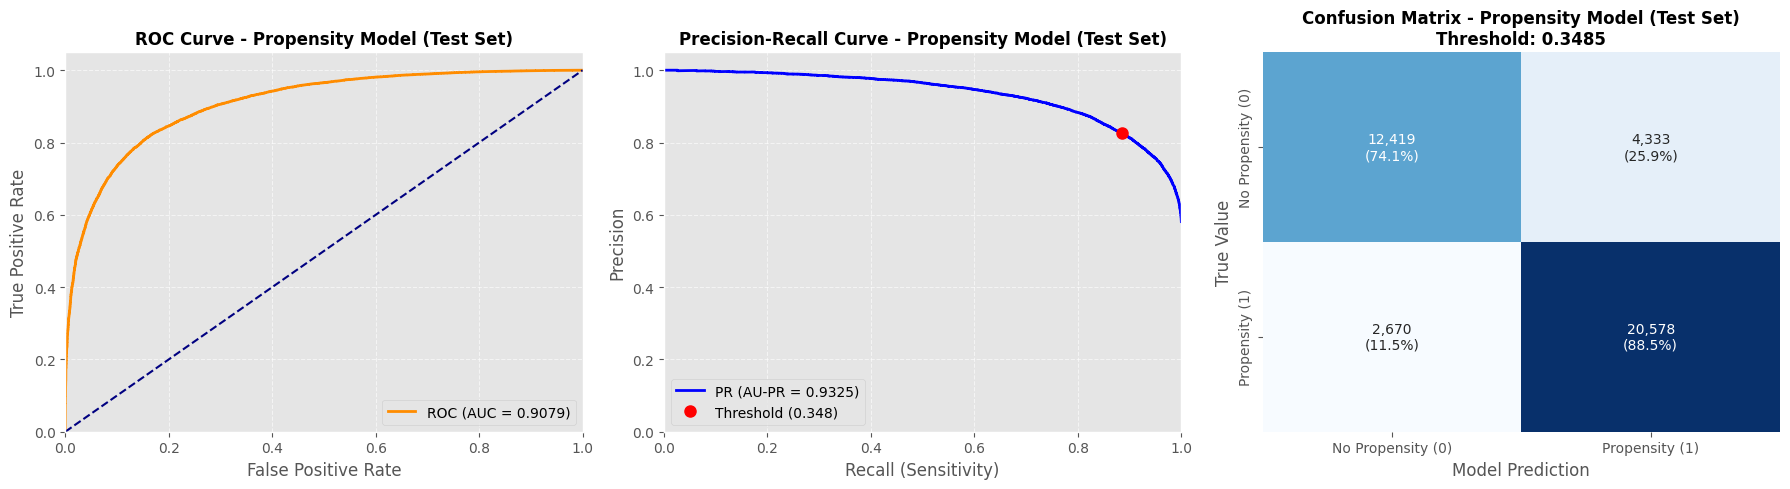

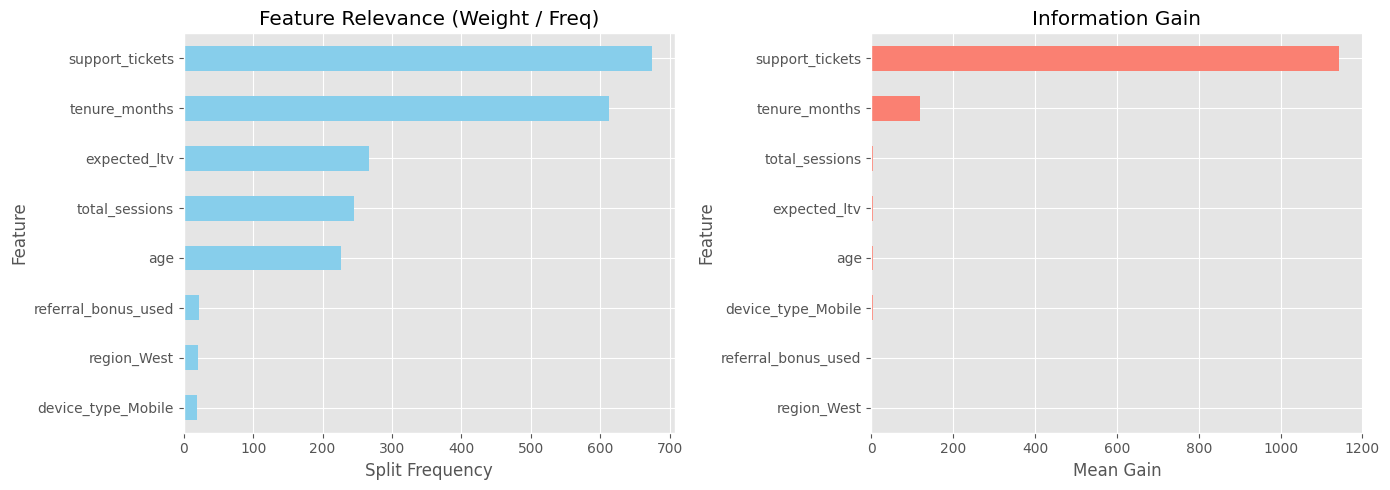

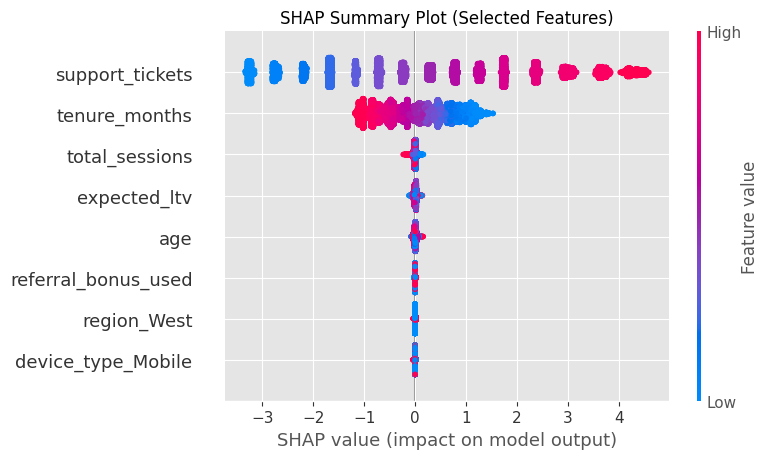

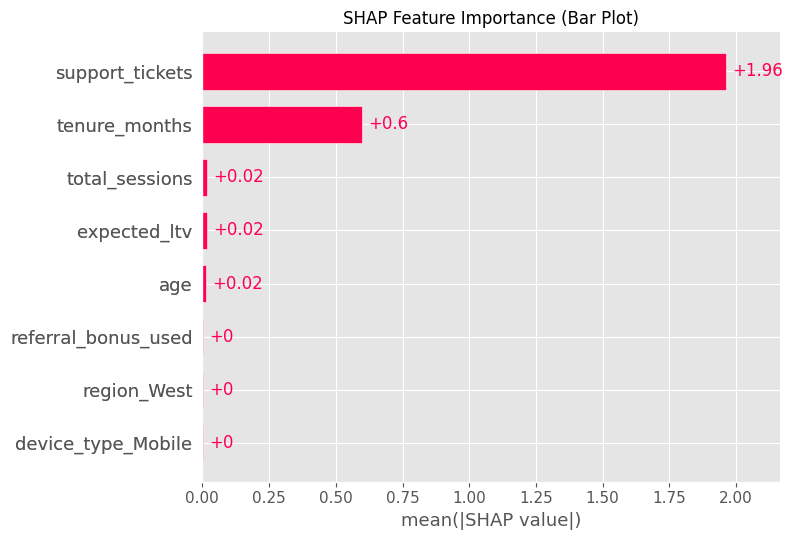

customer_id,churn,churn_pred_prob,churn_pred_label_optimal
23037,1,0.99585694,1
183691,1,0.9788205,1
190416,1,0.9886746,1
97505,1,0.8862061,1
177223,0,0.79746246,1
181100,1,0.6159504,1
3513,1,0.578627,1
118791,1,0.98395765,1
129846,0,0.07117139,0
115,1,0.82345986,1


In [0]:
results_xgboost = fit_xgb_churn_pipeline(
    df=df,
    target_col='churn',
    id_col='customer_id',
    test_size = 0.20,
    n_iter_search=20
)

df_test_predictions = results_xgboost['df_test_results']

target_col = 'churn'
pred_prob_col = f'{target_col}_pred_prob'
pred_label_col = f'{target_col}_pred_label_optimal'

display(df_test_predictions[['customer_id', target_col, pred_prob_col, pred_label_col]].head(20))

## LightGBM
---

In [0]:
def fit_lgb_pipeline(
    df: pd.DataFrame,
    target_col: str = 'churn',
    id_col: str = 'customer_id',
    test_size: float = 0.20,
    threshold_fs: str = 'median',
    n_iter_search: int = 15,
    cv_splits: int = 5,
    random_state: int = 1994
) -> dict:
    
    cols_to_drop = [target_col]
    if id_col in df.columns:
        cols_to_drop.append(id_col)
    
    X = df.drop(columns=cols_to_drop)
    y = df[target_col]

    # STRATIFIED TRAIN/TEST SPLIT
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )
    
  
    print(" 1. DATASET INFORMATION AND IMBALANCE RATIO")
    print("=" * 60)
    print(f"- Train set: {X_train.shape[0]} records | {X_train.shape[1]} features")
    print(f"- Test set:  {X_test.shape[0]} records | {X_test.shape[1]} features")

    num_neg = (y_train == 0).sum()
    num_pos = (y_train == 1).sum()
    scale_pos_weight = num_neg / num_pos if num_pos > 0 else 1.0
    print(f"- Calculated scale_pos_weight ratio: {scale_pos_weight:.3f}")

    # MODEL PIPELINE 
    lgb_base = lgb.LGBMClassifier(
        objective='binary',
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1
    )

    selector = SelectFromModel(
        estimator=lgb_base,
        threshold=threshold_fs,
        importance_getter='feature_importances_'
    )

    pipeline = Pipeline([
        ('feature_selection', selector),
        ('lgb', lgb_base)
    ])

    # HYPERPARAMETER TUNING WITH OPTUNA
    print("\n")
    print(" 2. OPTIMIZATION AND CROSS-VALIDATION (OPTUNA)")
    print("=" * 60)
    
    # CROSS VALIDATION STRATEGY
    cv_strategy = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    
    # OPTUNA OBJECTIVE FUNCTION
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_categorical('n_estimators', [100, 200, 300]),
            'num_leaves': trial.suggest_categorical('num_leaves', [15, 31, 63, 127]),
            'max_depth': trial.suggest_categorical('max_depth', [-1, 3, 5, 7, 9]),
            'learning_rate': trial.suggest_categorical('learning_rate', [0.01, 0.05, 0.1, 0.2]),
            'subsample': trial.suggest_categorical('subsample', [0.6, 0.8, 1.0]),
            'colsample_bytree': trial.suggest_categorical('colsample_bytree', [0.6, 0.8, 1.0]),
            'min_child_samples': trial.suggest_categorical('min_child_samples', [10, 20, 30, 50]),
            'reg_alpha': trial.suggest_categorical('reg_alpha', [0.0, 0.1, 1.0]),
            'reg_lambda': trial.suggest_categorical('reg_lambda', [0.0, 0.1, 1.0])
        }
        
        # CREATE MODEL
        model = lgb.LGBMClassifier(
            objective='binary',
            scale_pos_weight=scale_pos_weight,
            random_state=random_state,
            n_jobs=-1,
            verbose=-1,
            **params
        )
        
        # CREATE PIPELINE WITH FEATURE SELECTION
        selector = SelectFromModel(
            estimator=model,
            threshold=threshold_fs,
            importance_getter='feature_importances_'
        )
        
        trial_pipeline = Pipeline([
            ('feature_selection', selector),
            ('lgb', model)
        ])
        
        # MANUAL CV LOOP FOR PRUNING
        cv_scores = []
        for fold_idx, (train_idx, val_idx) in enumerate(cv_strategy.split(X_train, y_train)):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            trial_pipeline.fit(X_fold_train, y_fold_train)
            fold_score = f1_score(y_fold_val, trial_pipeline.predict(X_fold_val), zero_division=0)
            cv_scores.append(fold_score)
            
            trial.report(np.mean(cv_scores), fold_idx)
            
            if trial.should_prune():
                raise optuna.TrialPruned()
        
        return np.mean(cv_scores)
    
    # CREATE OPTUNA STUDY AND OPTIMIZE
    sampler = optuna.samplers.TPESampler(seed=random_state)
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=2
    )
    
    study = optuna.create_study(
        direction='maximize',
        sampler=sampler,
        pruner=pruner,
        study_name='lightgbm_propensity_optimization'
    )
    
    study.optimize(objective, n_trials=n_iter_search, show_progress_bar=True)
    
    # EXTRACT BEST HYPERPARAMETERS
    best_params = study.best_params
    cv_f1_mean = study.best_value
    best_trial = study.best_trial
    cv_f1_std = 0.0
    
    # PRUNING STATISTICS
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruned_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
    
    print("\n--- Cross-Validation Results (F1-Score Metric) ---")
    print(f" - Best CV F1-Score: {cv_f1_mean:.4f}")
    print(f" - Best Trial Number: {best_trial.number}")
    print(f" - Total Trials Started: {len(study.trials)}")
    print(f" - Trials Completed: {len(completed_trials)}")
    print(f" - Trials Pruned (Early Stopping): {len(pruned_trials)}")
    if len(pruned_trials) > 0:
        print(f" - Time Saved by Pruning: ~{len(pruned_trials) * 60}s (estimated)")
    
    print("\n--- Optimal Hyperparameters Found ---")
    cleaned_params = best_params.copy()
    for param, value in cleaned_params.items():
        print(f" - {param}: {value}")
    
    # TRAIN FINAL MODEL WITH BEST HYPERPARAMETERS
    best_model = lgb.LGBMClassifier(
        objective='binary',
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
        **best_params
    )
    
    best_selector = SelectFromModel(
        estimator=best_model,
        threshold=threshold_fs,
        importance_getter='feature_importances_'
    )
    
    best_pipeline = Pipeline([
        ('feature_selection', best_selector),
        ('lgb', best_model)
    ])
    
    best_pipeline.fit(X_train, y_train)
    best_model = best_pipeline.named_steps['lgb']
    best_selector = best_pipeline.named_steps['feature_selection']

    # FEATURE SELECTION REPORTING
    selected_mask = best_selector.get_support()
    selected_features = X.columns[selected_mask].tolist()
    removed_features = X.columns[~selected_mask].tolist()

    print("\n")
    print(" 3. FEATURE SELECTION")
    print("=" * 60)
    print(f" - Initial Predictor Features: {X.shape[1]}")
    print(f" - Selected Features:          {len(selected_features)}")
    print(f" - Discarded Features:         {len(removed_features)}")

    print("\n--- Kept Features List ---")
    for feat in selected_features:
        print(f"   - {feat}")

    print("\n--- Discarded Features List ---")
    for feat in removed_features:
        print(f"   - {feat}")

    # TRANSFORMATION
    X_train_sel = pd.DataFrame(best_selector.transform(X_train), columns=selected_features, index=X_train.index)
    X_test_sel = pd.DataFrame(best_selector.transform(X_test), columns=selected_features, index=X_test.index)

    # PROBABILITIES AND OPTIMAL THRESHOLD
    probs_train = best_model.predict_proba(X_train_sel)[:, 1]
    probs_test = best_model.predict_proba(X_test_sel)[:, 1]

    precisions_tr, recalls_tr, thresholds_tr = precision_recall_curve(y_train, probs_train)
    f1_scores_tr = (2 * precisions_tr * recalls_tr) / (precisions_tr + recalls_tr + 1e-8)
    best_idx = np.argmax(f1_scores_tr)
    best_threshold = thresholds_tr[best_idx] if best_idx < len(thresholds_tr) else 0.5

    print("\n" + "=" * 60)
    print(" 4. EVALUATION AND OPTIMAL THRESHOLD")
    print("=" * 60)
    print(f"- Optimal Threshold for F1-Score: {best_threshold:.4f}")

    preds_train_opt = (probs_train >= best_threshold).astype(int)
    preds_test_opt = (probs_test >= best_threshold).astype(int)

    # OUTPUT DATAFRAMES
    pred_prob_col = f'{target_col}_pred_prob'
    pred_label_col = f'{target_col}_pred_label_optimal'
    
    df_train_out = df.loc[X_train.index].copy()
    df_train_out[pred_prob_col] = probs_train
    df_train_out[pred_label_col] = preds_train_opt

    df_test_out = df.loc[X_test.index].copy()
    df_test_out[pred_prob_col] = probs_test
    df_test_out[pred_label_col] = preds_test_opt

    front_cols = [col for col in [id_col, target_col, pred_prob_col, pred_label_col] if col in df_train_out.columns]
    other_cols = [col for col in df_train_out.columns if col not in front_cols]
    
    df_train_out = df_train_out[front_cols + other_cols]
    df_test_out = df_test_out[front_cols + other_cols]

    # TRAIN/TEST METRICS
    def calculate_metrics(y_true, probs, preds, dataset_name):
        return {
            'Dataset': dataset_name,
            'Accuracy': accuracy_score(y_true, preds),
            'Precision': precision_score(y_true, preds, zero_division=0),
            'Recall': recall_score(y_true, preds, zero_division=0),
            'F1-Score (Opt)': f1_score(y_true, preds, zero_division=0),
            'AUC-ROC': roc_auc_score(y_true, probs),
            'AU-PR': average_precision_score(y_true, probs)
        }

    metrics_df = pd.DataFrame([
        calculate_metrics(y_train, probs_train, preds_train_opt, 'Train'),
        calculate_metrics(y_test, probs_test, preds_test_opt, 'Test')
    ]).set_index('Dataset')

    print("\n--- Final Performance Summary ---")
    print(metrics_df.round(4))

    # VISUALIZATIONS: ROC, PR CURVES AND CONFUSION MATRIX
    fig_eval, axes_eval = plt.subplots(1, 3, figsize=(18, 5))

    # ROC CURVE
    fpr, tpr, _ = roc_curve(y_test, probs_test)
    auc_roc = roc_auc_score(y_test, probs_test)
    
    axes_eval[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_roc:.4f})')
    axes_eval[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    axes_eval[0].set_xlim([0.0, 1.0])
    axes_eval[0].set_ylim([0.0, 1.05])
    axes_eval[0].set_xlabel('False Positive Rate')
    axes_eval[0].set_ylabel('True Positive Rate')
    axes_eval[0].set_title('ROC Curve - Propensity Model (Test Set)', fontsize=12, fontweight='bold')
    axes_eval[0].legend(loc="lower right")
    axes_eval[0].grid(True, linestyle='--', alpha=0.6)

    # PRECISION-RECALL CURVE
    prec_test, rec_test, _ = precision_recall_curve(y_test, probs_test)
    au_pr = average_precision_score(y_test, probs_test)
    
    axes_eval[1].plot(rec_test, prec_test, color='blue', lw=2, label=f'PR (AU-PR = {au_pr:.4f})')
    prec_opt = precision_score(y_test, preds_test_opt, zero_division=0)
    rec_opt = recall_score(y_test, preds_test_opt, zero_division=0)
    axes_eval[1].plot(rec_opt, prec_opt, 'ro', markersize=8, label=f'Threshold ({best_threshold:.3f})')
    
    axes_eval[1].set_xlim([0.0, 1.0])
    axes_eval[1].set_ylim([0.0, 1.05])
    axes_eval[1].set_xlabel('Recall (Sensitivity)')
    axes_eval[1].set_ylabel('Precision')
    axes_eval[1].set_title('Precision-Recall Curve - Propensity Model (Test Set)', fontsize=12, fontweight='bold')
    axes_eval[1].legend(loc="lower left")
    axes_eval[1].grid(True, linestyle='--', alpha=0.6)

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, preds_test_opt)
    cm_norm = confusion_matrix(y_test, preds_test_opt, normalize='true')
    
    labels = np.array([[f"{val:,}\n({norm:.1%})" for val, norm in zip(row_cm, row_norm)]
                       for row_cm, row_norm in zip(cm, cm_norm)])

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=axes_eval[2],
                xticklabels=['No Propensity (0)', 'Propensity (1)'],
                yticklabels=['No Propensity (0)', 'Propensity (1)'])
    axes_eval[2].set_xlabel('Model Prediction')
    axes_eval[2].set_ylabel('True Value')
    axes_eval[2].set_title(f'Confusion Matrix - Propensity Model (Test Set)\nThreshold: {best_threshold:.4f}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('evaluation_metrics_summary.png', dpi=150)
    plt.show()

    # FEATURE IMPORTANCE VISUALIZATIONS (SPLIT / WEIGHT AND GAIN)
    booster = best_model.booster_
    
    split_imp = pd.Series(booster.feature_importance(importance_type='split'), index=selected_features, name='Weight')
    gain_imp = pd.Series(booster.feature_importance(importance_type='gain'), index=selected_features, name='Gain')

    feat_imp = pd.DataFrame({'Weight': split_imp, 'Gain': gain_imp}).fillna(0)
    feat_imp.index.name = 'Feature'

    fig_imp, axes_imp = plt.subplots(1, 2, figsize=(14, 5))
    feat_imp.sort_values(by='Weight', ascending=True)['Weight'].tail(15).plot(
        kind='barh', ax=axes_imp[0], color='skyblue'
    )
    axes_imp[0].set_title('Feature Relevance (Split Frequency)')
    axes_imp[0].set_xlabel('Split Frequency')

    feat_imp.sort_values(by='Gain', ascending=True)['Gain'].tail(15).plot(
        kind='barh', ax=axes_imp[1], color='salmon'
    )
    axes_imp[1].set_title('Information Gain')
    axes_imp[1].set_xlabel('Mean Gain')
    plt.tight_layout()
    plt.savefig('lgb_native_feature_importance.png', dpi=150)
    plt.show()

    # SHAP VISUALIZATIONS
    
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer(X_test_sel)

    plt.figure(figsize=(10, 6))
    plt.title('SHAP Summary Plot (Selected Features)', fontsize=12)
    shap.plots.beeswarm(shap_values, show=False)
    plt.tight_layout()
    plt.savefig('shap_summary_plot.png', dpi=150)
    plt.show()

    print("\n")


    plt.figure(figsize=(10, 6))
    plt.title('SHAP Feature Importance (Bar Plot)', fontsize=12)
    shap.plots.bar(shap_values, show=False)
    plt.tight_layout()
    plt.savefig('shap_bar_importance.png', dpi=150)
    plt.show()

    return {
        'best_pipeline': best_pipeline,
        'best_model': best_model,
        'best_params': cleaned_params,
        'cv_f1_score_mean': cv_f1_mean,
        'cv_f1_score_std': cv_f1_std,
        'optuna_study': study,
        'selected_features': selected_features,
        'removed_features': removed_features,
        'optimal_threshold': best_threshold,
        'metrics': metrics_df,
        'df_train_results': df_train_out,
        'df_test_results': df_test_out,
        'feature_importance': feat_imp,
        'shap_values': shap_values,
        'explainer': explainer
    }

[I 2026-08-11 07:15:33,403] A new study created in memory with name: lightgbm_propensity_optimization


 1. DATASET INFORMATION AND IMBALANCE RATIO
- Train set: 160000 records | 16 features
- Test set:  40000 records | 16 features
- Calculated scale_pos_weight ratio: 0.721


 2. OPTIMIZATION AND CROSS-VALIDATION (OPTUNA)


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-08-11 07:16:40,562] Trial 0 finished with value: 0.8412090515914213 and parameters: {'n_estimators': 300, 'num_leaves': 127, 'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 1.0, 'min_child_samples': 50, 'reg_alpha': 1.0, 'reg_lambda': 1.0}. Best is trial 0 with value: 0.8412090515914213.
[I 2026-08-11 07:16:55,162] Trial 1 finished with value: 0.8409135116872832 and parameters: {'n_estimators': 100, 'num_leaves': 63, 'max_depth': 5, 'learning_rate': 0.2, 'subsample': 1.0, 'colsample_bytree': 0.6, 'min_child_samples': 30, 'reg_alpha': 1.0, 'reg_lambda': 1.0}. Best is trial 0 with value: 0.8412090515914213.
[I 2026-08-11 07:17:37,289] Trial 2 finished with value: 0.8422681008541998 and parameters: {'n_estimators': 300, 'num_leaves': 15, 'max_depth': 9, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 0.6, 'min_child_samples': 10, 'reg_alpha': 1.0, 'reg_lambda': 0.1}. Best is trial 2 with value: 0.8422681008541998.
[I 2026-08-11 07:18:19,28

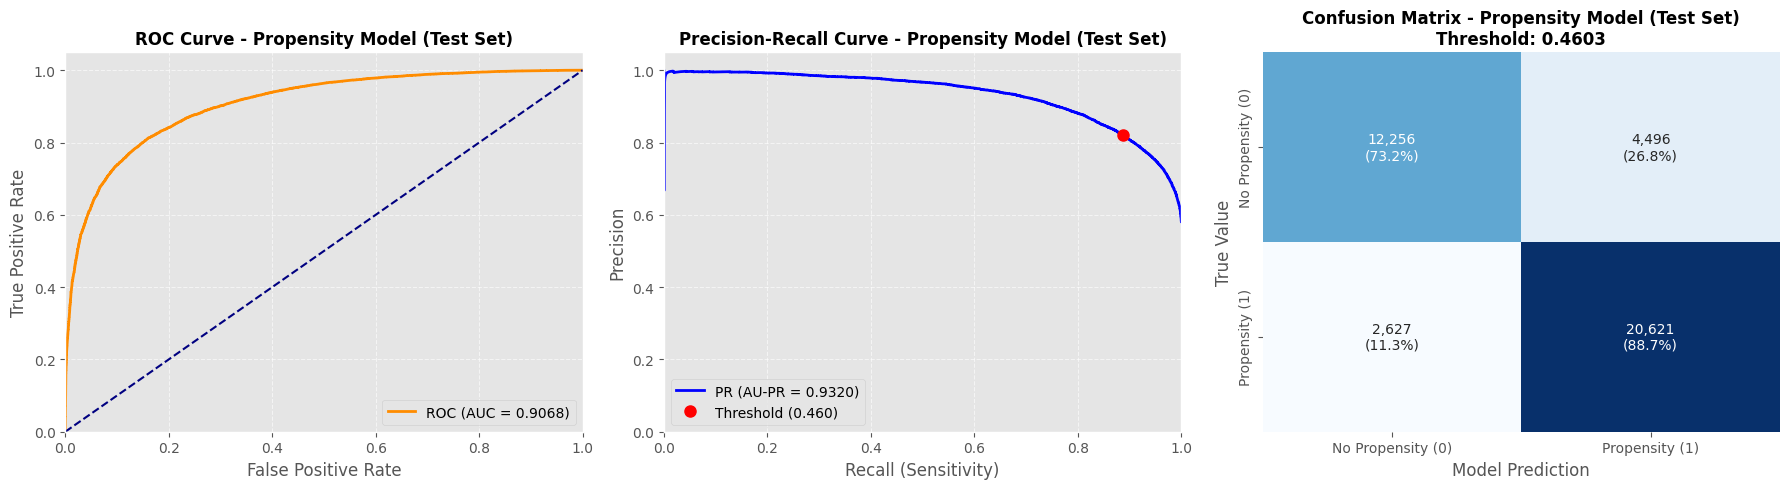

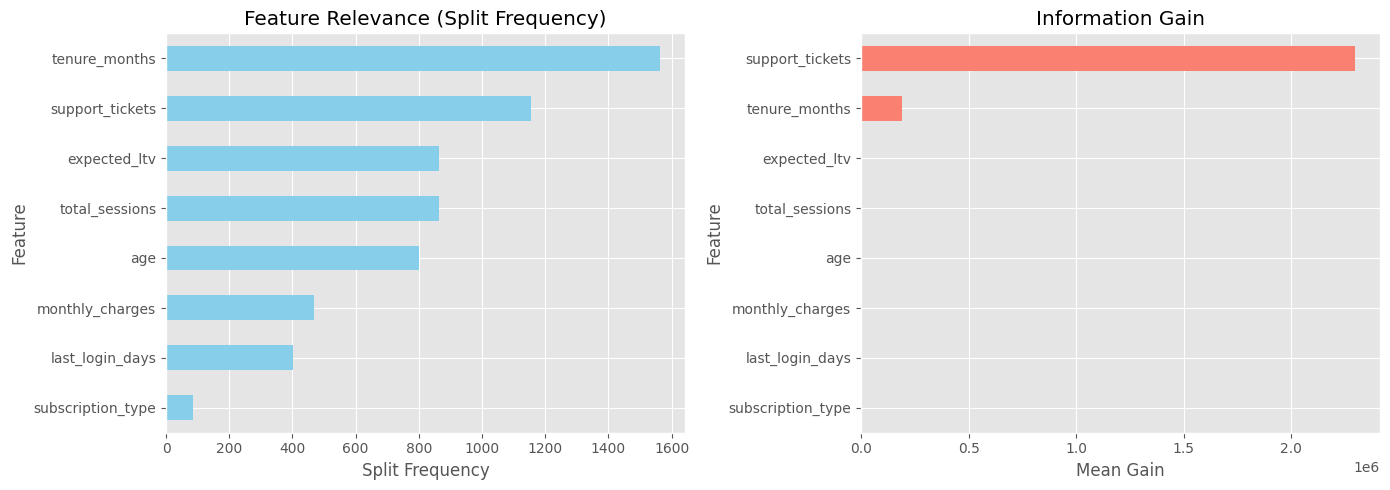

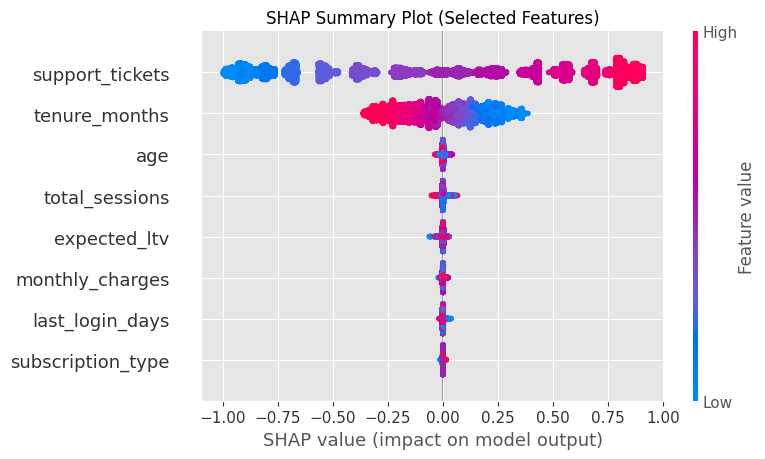

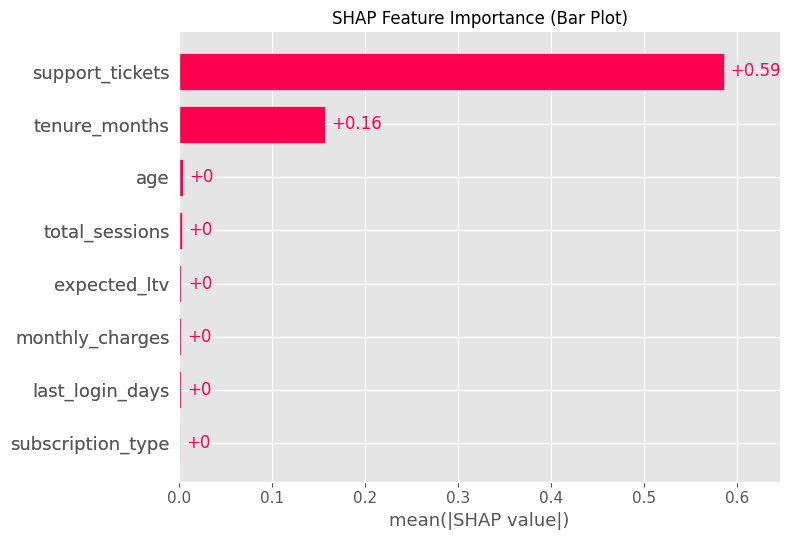

customer_id,churn,churn_pred_prob,churn_pred_label_optimal
186328,1,0.714180173668782,1
187734,1,0.6329571949141496,1
69078,1,0.7564583092215422,1
8478,0,0.31767724762354255,0
84304,1,0.6649593130240716,1
73141,1,0.6851678801137382,1
121087,0,0.4395496810113532,0
144316,1,0.7098822545628486,1
91676,0,0.4976883581732266,1
191399,0,0.5063234872553523,1


In [0]:
results_lgbm = fit_lgb_pipeline(
    df=df,
    target_col='churn',
    id_col='customer_id',
    test_size=0.20,
    n_iter_search=20
)
 

df_test_predictions = results_lgbm['df_test_results']

target_col = 'churn'
pred_prob_col = f'{target_col}_pred_prob'
pred_label_col = f'{target_col}_pred_label_optimal'

display(df_test_predictions[['customer_id', target_col, pred_prob_col, pred_label_col]].head(20))

## Decision Tree
---

In [0]:
def fit_dt_churn_pipeline(
    df: pd.DataFrame,
    target_col: str = 'churn',
    id_col: str = 'customer_id',
    test_size: float = 0.20,
    class_weight: str | dict | None = 'balanced',
    threshold_fs: str = 'median',
    n_iter_search: int = 15,
    cv_splits: int = 5,
    max_depth_plot: int | None = 3,
    random_state: int = 42
) -> dict:
    
    cols_to_drop = [target_col]
    if id_col in df.columns:
        cols_to_drop.append(id_col)
    
    X = df.drop(columns=cols_to_drop)
    y = df[target_col]

    # STRATIFIED TRAIN/TEST SPLIT
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    print(" 1. DATASET INFORMATION AND IMBALANCE RATIO")
    print("=" * 60)
    print(f"- Model Algorithm: Decision Tree Classifier")
    print(f"- Train set: {X_train.shape[0]} records | {X_train.shape[1]} features")
    print(f"- Test set:  {X_test.shape[0]} records | {X_test.shape[1]} features")

    num_neg = (y_train == 0).sum()
    num_pos = (y_train == 1).sum()
    imbalance_ratio = num_neg / num_pos if num_pos > 0 else 1.0
    print(f"- Class distribution in Train -> Negative (0): {num_neg:,} | Positive (1): {num_pos:,}")
    print(f"- Calculated imbalance ratio (neg/pos): {imbalance_ratio:.2f}:1")
    print(f"- Decision Tree Class weight strategy: Optimized by Optuna")

    # BASE DECISION TREE MODEL & SELECTOR
    dt_base = DecisionTreeClassifier(
        class_weight=class_weight,
        random_state=random_state
    )

    selector = SelectFromModel(
        estimator=dt_base,
        threshold=threshold_fs,
        importance_getter='feature_importances_'
    )

    pipeline = Pipeline([
        ('feature_selection', selector),
        ('dt', dt_base)
    ])

    # HYPERPARAMETER TUNING WITH OPTUNA
    print("\n")
    print(" 2. OPTIMIZATION AND CROSS-VALIDATION (OPTUNA)")
    print("=" * 60)
    
    # CROSS VALIDATION STRATEGY
    cv_strategy = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    
    # OPTUNA OBJECTIVE FUNCTION
    def objective(trial):
        params = {
            'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
            'max_depth': trial.suggest_categorical('max_depth', [3, 4, 5, 6, 8, 10]),
            'min_samples_split': trial.suggest_categorical('min_samples_split', [10, 20, 50, 100]),
            'min_samples_leaf': trial.suggest_categorical('min_samples_leaf', [5, 10, 20, 50, 100]),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'ccp_alpha': trial.suggest_categorical('ccp_alpha', [0.0, 0.001, 0.005, 0.01, 0.02]),
            'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])
        }
        
        # CREATE MODEL
        model = DecisionTreeClassifier(
            random_state=random_state,
            **params
        )
        
        # CREATE PIPELINE WITH FEATURE SELECTION
        selector = SelectFromModel(
            estimator=model,
            threshold=threshold_fs,
            importance_getter='feature_importances_'
        )
        
        trial_pipeline = Pipeline([
            ('feature_selection', selector),
            ('dt', model)
        ])
        
        # MANUAL CV LOOP FOR PRUNING
        cv_scores = []
        for fold_idx, (train_idx, val_idx) in enumerate(cv_strategy.split(X_train, y_train)):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            trial_pipeline.fit(X_fold_train, y_fold_train)
            fold_score = f1_score(y_fold_val, trial_pipeline.predict(X_fold_val), zero_division=0)
            cv_scores.append(fold_score)
            
            trial.report(np.mean(cv_scores), fold_idx)
            
            if trial.should_prune():
                raise optuna.TrialPruned()
        
        return np.mean(cv_scores)
    
    # CREATE OPTUNA STUDY AND OPTIMIZE
    sampler = optuna.samplers.TPESampler(seed=random_state)
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=2
    )
    
    study = optuna.create_study(
        direction='maximize',
        sampler=sampler,
        pruner=pruner,
        study_name='decision_tree_propensity_optimization'
    )
    
    study.optimize(objective, n_trials=n_iter_search, show_progress_bar=True)
    
    # EXTRACT BEST HYPERPARAMETERS
    best_params = study.best_params
    cv_f1_mean = study.best_value
    best_trial = study.best_trial
    cv_f1_std = 0.0
    
    # PRUNING STATISTICS
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruned_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
    
    print("\n--- Cross-Validation Results (F1-Score Metric) ---")
    print(f" - Best CV F1-Score: {cv_f1_mean:.4f}")
    print(f" - Best Trial Number: {best_trial.number}")
    print(f" - Total Trials Started: {len(study.trials)}")
    print(f" - Trials Completed: {len(completed_trials)}")
    print(f" - Trials Pruned (Early Stopping): {len(pruned_trials)}")
    if len(pruned_trials) > 0:
        print(f" - Time Saved by Pruning: ~{len(pruned_trials) * 5}s (estimated)")
    
    print("\n--- Optimal Hyperparameters Found ---")
    cleaned_params = best_params.copy()
    for param, value in cleaned_params.items():
        print(f" - {param}: {value}")
    
    # TRAIN FINAL MODEL WITH BEST HYPERPARAMETERS
    best_model = DecisionTreeClassifier(
        random_state=random_state,
        **best_params
    )
    
    best_selector = SelectFromModel(
        estimator=best_model,
        threshold=threshold_fs,
        importance_getter='feature_importances_'
    )
    
    best_pipeline = Pipeline([
        ('feature_selection', best_selector),
        ('dt', best_model)
    ])
    
    best_pipeline.fit(X_train, y_train)
    best_model = best_pipeline.named_steps['dt']
    best_selector = best_pipeline.named_steps['feature_selection']

    # FEATURE SELECTION REPORTING
    all_feature_names = X_train.columns.tolist()
    selected_mask = best_selector.get_support()
    selected_features = [f for f, s in zip(all_feature_names, selected_mask) if s]
    removed_features = [f for f, s in zip(all_feature_names, selected_mask) if not s]

    print("\n")
    print(" 3. FEATURE SELECTION (DECISION TREE IMPORTANCE)")
    print("=" * 60)
    print(f" - Initial Predictor Features: {len(all_feature_names)}")
    print(f" - Selected Features:          {len(selected_features)}")
    print(f" - Discarded Features:         {len(removed_features)}")

    print("\n--- Kept Features List ---")
    for feat in selected_features:
        print(f"   - {feat}")

    print("\n--- Discarded Features List ---")
    for feat in removed_features:
        print(f"   - {feat}")

    # PROBABILITIES VIA PIPELINE
    probs_train = best_pipeline.predict_proba(X_train)[:, 1]
    probs_test = best_pipeline.predict_proba(X_test)[:, 1]

    # OPTIMAL THRESHOLD
    precisions_tr, recalls_tr, thresholds_tr = precision_recall_curve(y_train, probs_train)
    f1_scores_tr = (2 * precisions_tr * recalls_tr) / (precisions_tr + recalls_tr + 1e-8)
    best_idx = np.argmax(f1_scores_tr)
    best_threshold = thresholds_tr[best_idx] if best_idx < len(thresholds_tr) else 0.5

    print("\n")
    print(" 4. DECISION TREE EVALUATION & OPTIMAL THRESHOLD")
    print("=" * 60)
    print(f"- Optimal Threshold for F1-Score (calculated on Train): {best_threshold:.4f}")

    preds_train_opt = (probs_train >= best_threshold).astype(int)
    preds_test_opt = (probs_test >= best_threshold).astype(int)

    # OUTPUT DATAFRAMES
    pred_prob_col = f'{target_col}_pred_prob'
    pred_label_col = f'{target_col}_pred_label_optimal'
    
    df_train_out = df.loc[X_train.index].copy()
    df_train_out[pred_prob_col] = probs_train
    df_train_out[pred_label_col] = preds_train_opt

    df_test_out = df.loc[X_test.index].copy()
    df_test_out[pred_prob_col] = probs_test
    df_test_out[pred_label_col] = preds_test_opt

    front_cols = [col for col in [id_col, target_col, pred_prob_col, pred_label_col] if col in df_train_out.columns]
    other_cols = [col for col in df_train_out.columns if col not in front_cols]
    
    df_train_out = df_train_out[front_cols + other_cols]
    df_test_out = df_test_out[front_cols + other_cols]

    # TRAIN/TEST METRICS
    def calculate_metrics(y_true, probs, preds, dataset_name):
        return {
            'Dataset': dataset_name,
            'Accuracy': accuracy_score(y_true, preds),
            'Precision': precision_score(y_true, preds, zero_division=0),
            'Recall': recall_score(y_true, preds, zero_division=0),
            'F1-Score (Opt)': f1_score(y_true, preds, zero_division=0),
            'AUC-ROC': roc_auc_score(y_true, probs),
            'AU-PR': average_precision_score(y_true, probs)
        }

    metrics_df = pd.DataFrame([
        calculate_metrics(y_train, probs_train, preds_train_opt, 'Train'),
        calculate_metrics(y_test, probs_test, preds_test_opt, 'Test')
    ]).set_index('Dataset')

    print("\n--- Final Performance Summary (Propensity Model - Decision Tree) ---")
    print(metrics_df.round(4))

    # EVALUATION METRICS (ROC, PR, CONFUSION MATRIX)
    fig_eval, axes_eval = plt.subplots(1, 3, figsize=(18, 5))

    # ROC CURVE
    fpr, tpr, _ = roc_curve(y_test, probs_test)
    auc_roc = roc_auc_score(y_test, probs_test)
    
    axes_eval[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_roc:.4f})')
    axes_eval[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    axes_eval[0].set_xlim([0.0, 1.0])
    axes_eval[0].set_ylim([0.0, 1.05])
    axes_eval[0].set_xlabel('False Positive Rate')
    axes_eval[0].set_ylabel('True Positive Rate')
    axes_eval[0].set_title('ROC Curve - Propensity Model / Decision Tree (Test Set)', fontsize=12, fontweight='bold')
    axes_eval[0].legend(loc="lower right")
    axes_eval[0].grid(True, linestyle='--', alpha=0.6)

    # PRECISION-RECALL CURVE
    prec_test, rec_test, _ = precision_recall_curve(y_test, probs_test)
    au_pr = average_precision_score(y_test, probs_test)
    
    axes_eval[1].plot(rec_test, prec_test, color='blue', lw=2, label=f'PR (AU-PR = {au_pr:.4f})')
    prec_opt = precision_score(y_test, preds_test_opt, zero_division=0)
    rec_opt = recall_score(y_test, preds_test_opt, zero_division=0)
    axes_eval[1].plot(rec_opt, prec_opt, 'ro', markersize=8, label=f'Threshold ({best_threshold:.3f})')
    
    axes_eval[1].set_xlim([0.0, 1.0])
    axes_eval[1].set_ylim([0.0, 1.05])
    axes_eval[1].set_xlabel('Recall (Sensitivity)')
    axes_eval[1].set_ylabel('Precision')
    axes_eval[1].set_title('PR Curve - Propensity Model / Decision Tree (Test Set)', fontsize=12, fontweight='bold')
    axes_eval[1].legend(loc="lower left")
    axes_eval[1].grid(True, linestyle='--', alpha=0.6)

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, preds_test_opt)
    cm_norm = confusion_matrix(y_test, preds_test_opt, normalize='true')
    
    labels = np.array([[f"{val:,}\n({norm:.1%})" for val, norm in zip(row_cm, row_norm)]
                       for row_cm, row_norm in zip(cm, cm_norm)])

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=axes_eval[2],
                xticklabels=['No Propensity (0)', 'Propensity (1)'],
                yticklabels=['No Propensity (0)', 'Propensity (1)'])
    axes_eval[2].set_xlabel('Model Prediction')
    axes_eval[2].set_ylabel('True Value')
    axes_eval[2].set_title(f'Confusion Matrix - Propensity Model / Decision Tree\nThreshold: {best_threshold:.4f}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('dt_evaluation_metrics_summary.png', dpi=150)
    plt.show()
    plt.close()
    print("\n")

    # ==============================================================================
    # VISUALIZACIÓN 2: DECISION TREE DIAGRAM
    # ==============================================================================
    plt.figure(figsize=(22, 10), dpi=300)
    plot_tree(
        best_model,
        max_depth=max_depth_plot,
        feature_names=selected_features,
        class_names=['No Propensity (0)', 'Propensity (1)'],
        filled=True,
        rounded=True,
        impurity=True,
        proportion=False,
        precision=2,
        fontsize=8
    )
    title_depth = f"First {max_depth_plot} Levels" if max_depth_plot is not None else "Full Tree"
    plt.title(f'Decision Tree Structure ({title_depth})', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('decision_tree_diagram.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("\n")

    # ==============================================================================
    # VISUALIZACIÓN 3: NATIVE FEATURE IMPORTANCE
    # ==============================================================================
    feat_imp = pd.Series(best_model.feature_importances_, index=selected_features, name='Gini Importance')
    feat_imp = feat_imp.sort_values(ascending=True)

    plt.figure(figsize=(8, 5))
    feat_imp.tail(15).plot(kind='barh', color='skyblue')
    plt.title('Decision Tree Feature Importance (Gini)', fontsize=12, fontweight='bold')
    plt.xlabel('Gini Importance')
    plt.tight_layout()
    plt.savefig('dt_native_feature_importance.png', dpi=150)
    plt.show()
    plt.close()
    print("\n")

    # ==============================================================================
    # VISUALIZACIÓN 4 & 5: SHAP PLOTS
    # ==============================================================================
    X_test_sel = pd.DataFrame(
        best_selector.transform(X_test),
        columns=selected_features,
        index=X_test.index
    )

    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer(X_test_sel)

    if len(shap_values.shape) == 3:
        shap_values_to_plot = shap_values[:, :, 1]
    else:
        shap_values_to_plot = shap_values

    # SHAP Beeswarm
    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_values_to_plot, show=False)
    plt.title('Decision Tree - SHAP Summary Plot', fontsize=12, pad=15)
    plt.tight_layout()
    plt.savefig('dt_shap_summary_plot.png', dpi=150)
    plt.show()
    plt.close()
    print("\n")
    
    # SHAP Bar Plot
    plt.figure(figsize=(10, 6))
    shap.plots.bar(shap_values_to_plot, show=False)
    plt.title('Decision Tree - SHAP Feature Importance (Bar Plot)', fontsize=12, pad=15)
    plt.tight_layout()
    plt.savefig('dt_shap_bar_importance.png', dpi=150)
    plt.show()
    plt.close()

    return {
        'best_pipeline': best_pipeline,
        'best_model': best_model,
        'best_params': cleaned_params,
        'cv_f1_score_mean': cv_f1_mean,
        'cv_f1_score_std': cv_f1_std,
        'optuna_study': study,
        'selected_features': selected_features,
        'removed_features': removed_features,
        'optimal_threshold': best_threshold,
        'metrics': metrics_df,
        'df_train_results': df_train_out,
        'df_test_results': df_test_out,
        'feature_importance': feat_imp,
        'shap_values': shap_values,
        'explainer': explainer
    }

[I 2026-08-11 07:31:26,939] A new study created in memory with name: decision_tree_propensity_optimization


 1. DATASET INFORMATION AND IMBALANCE RATIO
- Model Algorithm: Decision Tree Classifier
- Train set: 160000 records | 16 features
- Test set:  40000 records | 16 features
- Class distribution in Train -> Negative (0): 67,010 | Positive (1): 92,990
- Calculated imbalance ratio (neg/pos): 0.72:1
- Decision Tree Class weight strategy: Optimized by Optuna


 2. OPTIMIZATION AND CROSS-VALIDATION (OPTUNA)


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-08-11 07:31:29,232] Trial 0 finished with value: 0.8222270962335667 and parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 100, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.0, 'class_weight': None}. Best is trial 0 with value: 0.8222270962335667.
[I 2026-08-11 07:31:31,748] Trial 1 finished with value: 0.8030020426945127 and parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 100, 'max_features': 'log2', 'ccp_alpha': 0.01, 'class_weight': None}. Best is trial 0 with value: 0.8222270962335667.
[I 2026-08-11 07:31:39,414] Trial 2 finished with value: 0.827880760537899 and parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 50, 'max_features': None, 'ccp_alpha': 0.005, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.827880760537899.
[I 2026-08-11 07:31:42,097] Trial 3 finished with value: 0.6976816056712678 and parameters: {'criterion': '

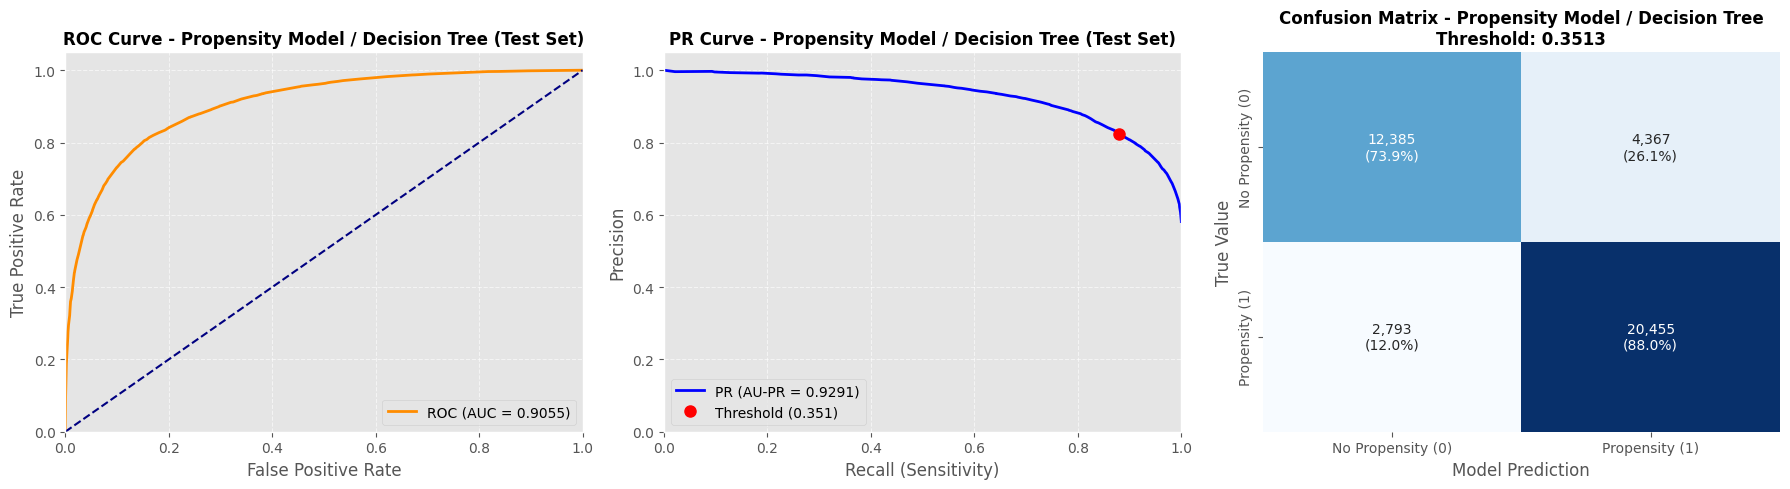

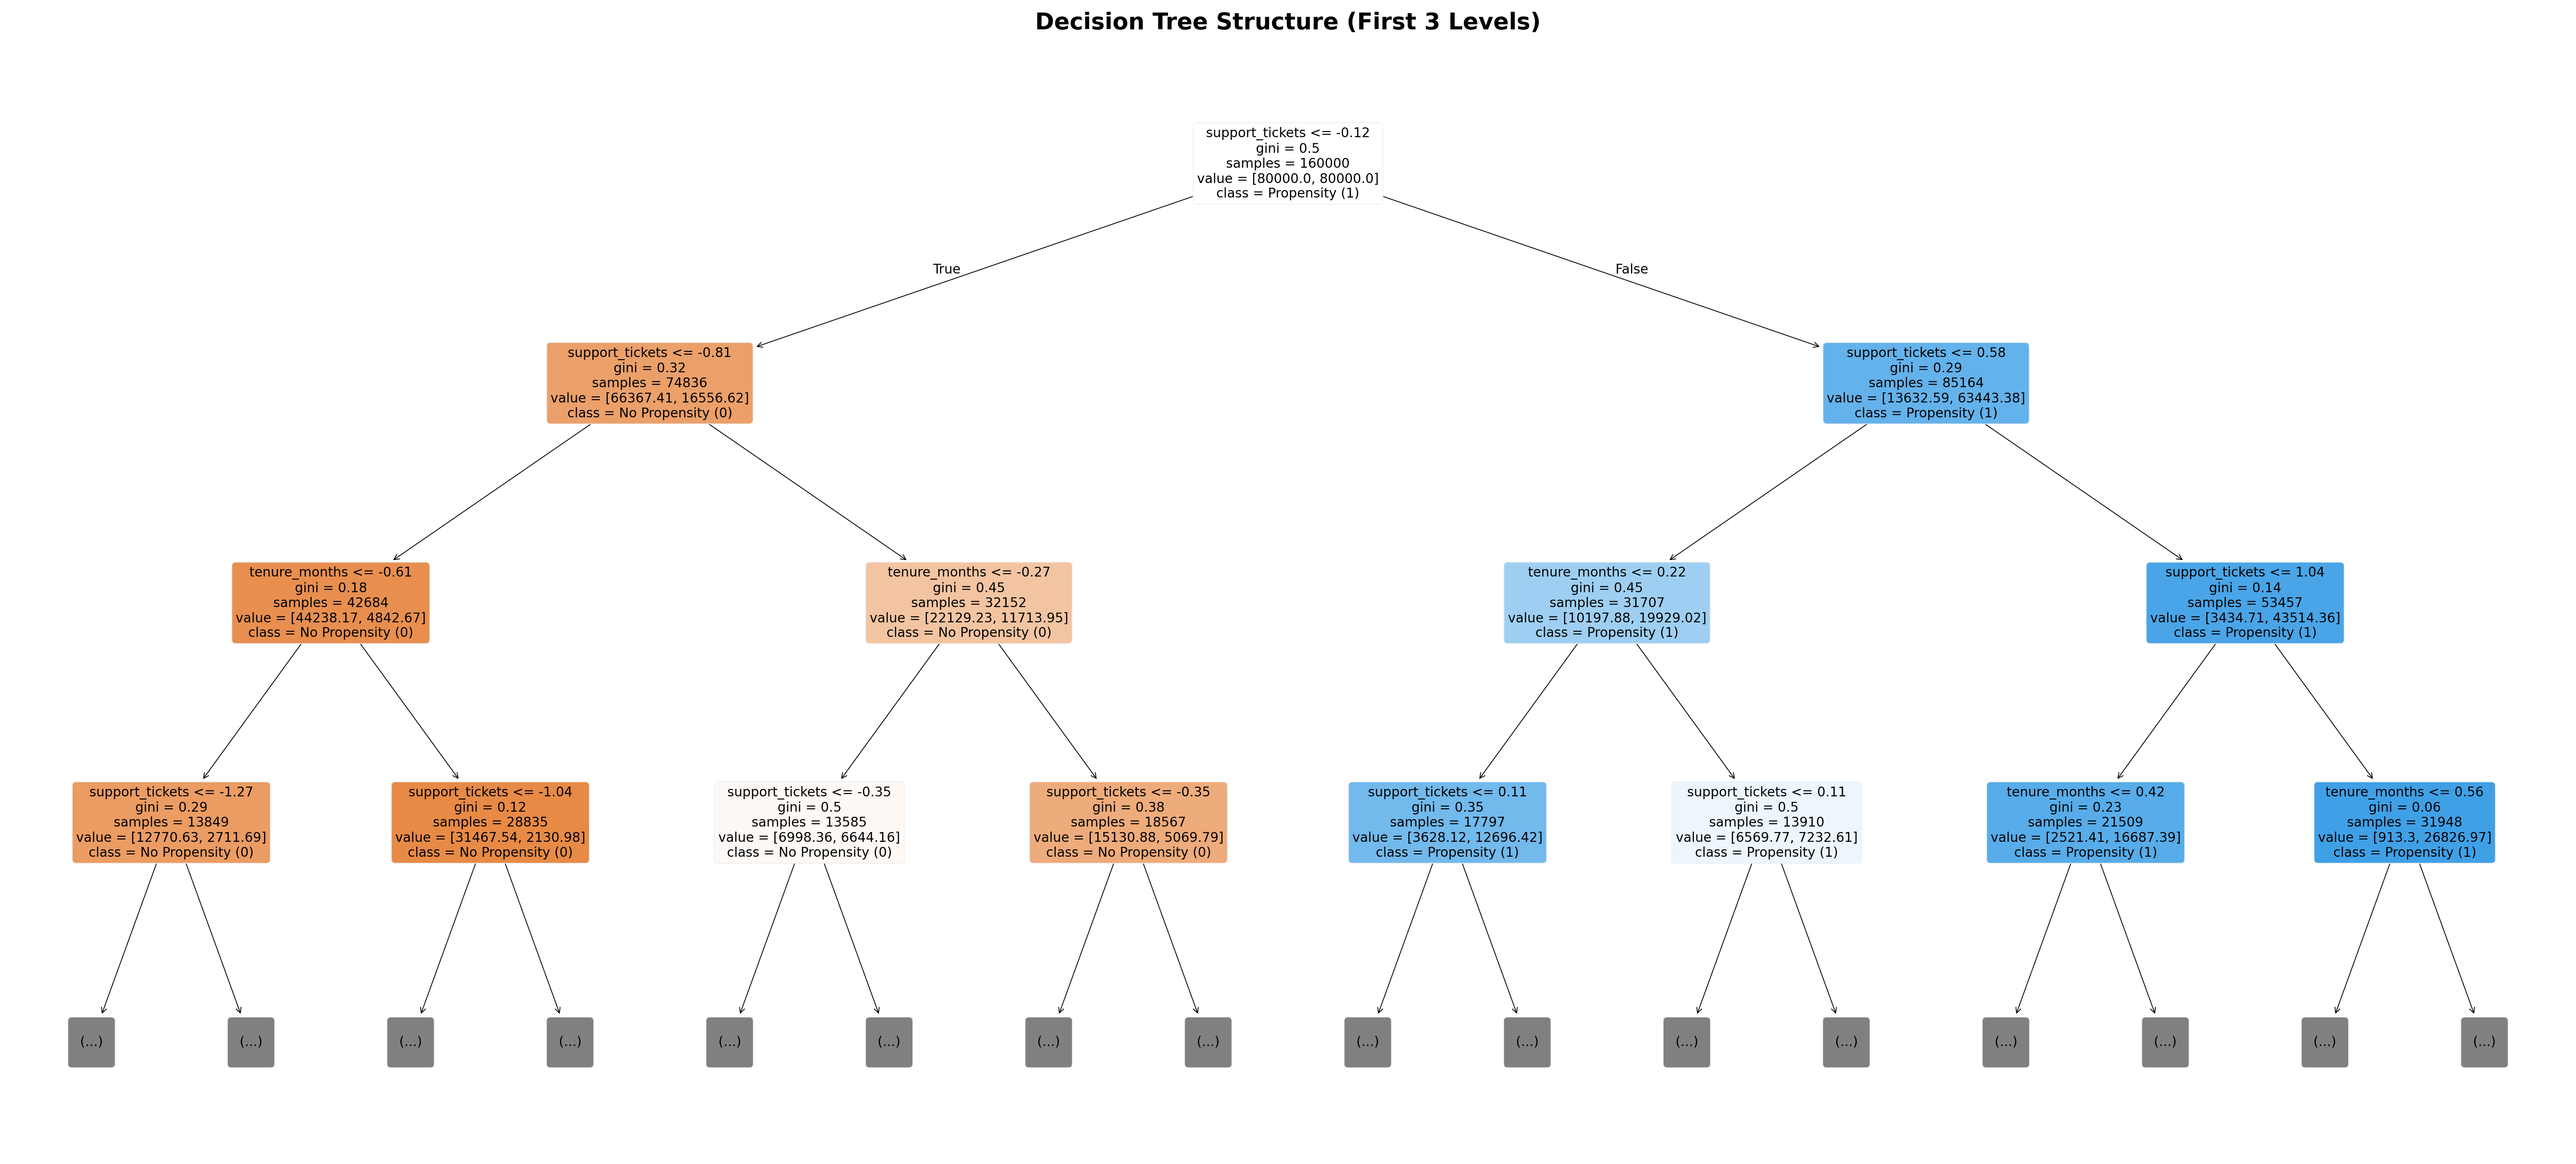

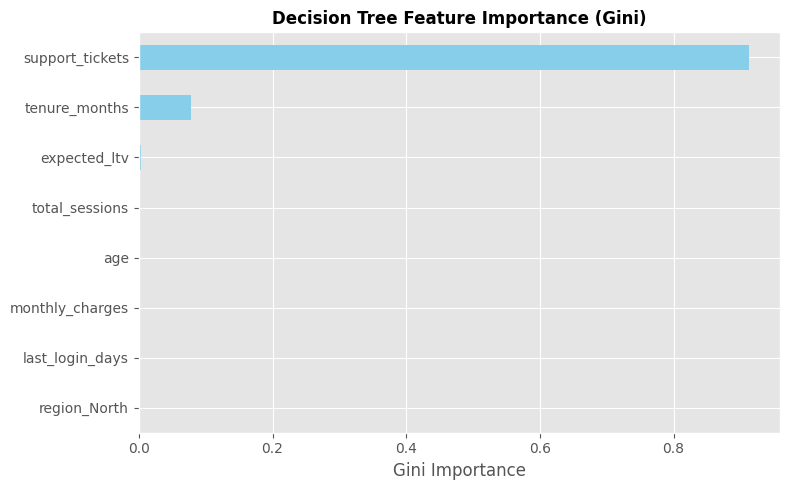

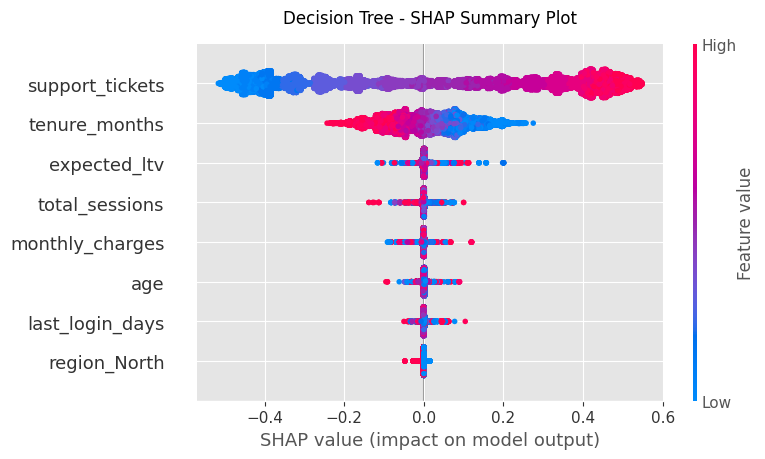

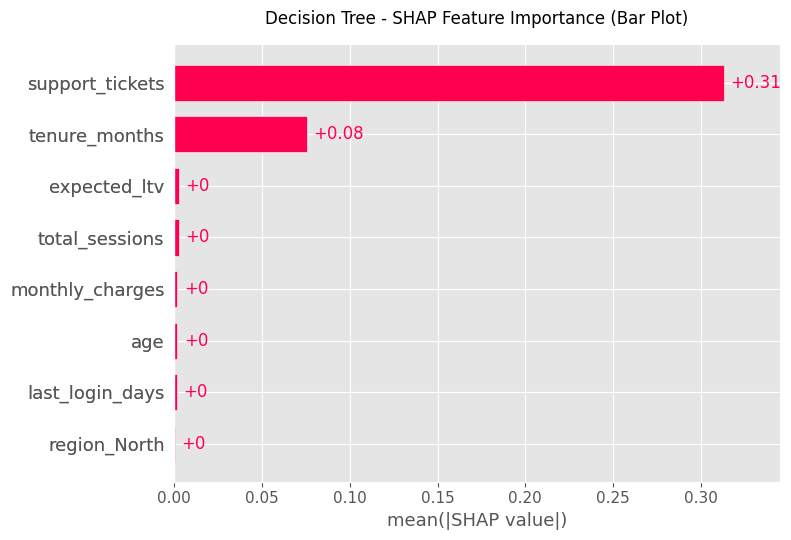

customer_id,churn,churn_pred_prob,churn_pred_label_optimal
23037,1,1.0,1
183691,1,0.9897329172325423,1
190416,1,0.9897329172325423,1
97505,1,0.8626650575224692,1
177223,0,0.7628015648937403,1
181100,1,0.5865805515944748,1
3513,1,0.5925226188684256,1
118791,1,0.9933466744515299,1
129846,0,0.049248651426279925,0
115,1,0.8215848877894854,1


In [0]:
results_dt = fit_dt_churn_pipeline(
    df=df,
    target_col='churn',
    id_col='customer_id',
    test_size=0.20,
    n_iter_search=20
)

df_test_predictions = results_dt['df_test_results']

target_col = 'churn'
pred_prob_col = f'{target_col}_pred_prob'
pred_label_col = f'{target_col}_pred_label_optimal'

display(df_test_predictions[['customer_id', target_col, pred_prob_col, pred_label_col]].head(20))

## Random Forest
---

In [0]:
def fit_rf_churn_pipeline(
    df: pd.DataFrame,
    target_col: str = 'churn',
    id_col: str = 'customer_id',
    test_size: float = 0.20,
    class_weight: str | dict | None = 'balanced',
    threshold_fs: str = 'median',
    n_iter_search: int = 20,
    cv_splits: int = 5,
    random_state: int = 42
) -> dict:
    
    cols_to_drop = [target_col]
    if id_col in df.columns:
        cols_to_drop.append(id_col)
    
    X = df.drop(columns=cols_to_drop)
    y = df[target_col]

    # STRATIFIED TRAIN/TEST SPLIT
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    print(" 1. DATASET INFORMATION AND IMBALANCE RATIO")
    print("=" * 60)
    print(f"- Model Algorithm: Random Forest Classifier")
    print(f"- Train set: {X_train.shape[0]} records | {X_train.shape[1]} features")
    print(f"- Test set:  {X_test.shape[0]} records | {X_test.shape[1]} features")

    num_neg = (y_train == 0).sum()
    num_pos = (y_train == 1).sum()
    imbalance_ratio = num_neg / num_pos if num_pos > 0 else 1.0
    print(f"- Class distribution in Train -> Negative (0): {num_neg:,} | Positive (1): {num_pos:,}")
    print(f"- Calculated imbalance ratio (neg/pos): {imbalance_ratio:.2f}:1")
    print(f"- Random Forest Class weight strategy: Optimized by Optuna")

    # HYPERPARAMETER TUNING WITH OPTUNA
    print("\n")
    print(" 2. OPTIMIZATION AND CROSS-VALIDATION (OPTUNA)")
    print("=" * 60)
    
    # CROSS VALIDATION STRATEGY
    cv_strategy = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    
    # OPTUNA OBJECTIVE FUNCTION
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_categorical('n_estimators', [100, 200, 300, 500]),
            'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
            'max_depth': trial.suggest_categorical('max_depth', [10, 20, 30, 40, 50, None]),
            'min_samples_split': trial.suggest_categorical('min_samples_split', [2, 5, 10, 20]),
            'min_samples_leaf': trial.suggest_categorical('min_samples_leaf', [1, 2, 4, 8]),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'max_samples': trial.suggest_categorical('max_samples', [0.7, 0.8, 0.9, None]) if trial.params.get('bootstrap', True) else None,
            'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample'])
        }
        
        # REMOVE max_samples IF bootstrap=False
        if not params['bootstrap']:
            params.pop('max_samples', None)
        
        # CREATE MODEL
        model = RandomForestClassifier(
            random_state=random_state,
            n_jobs=-1,
            **params
        )
        
        # CREATE PIPELINE WITH FEATURE SELECTION
        selector = SelectFromModel(
            estimator=model,
            threshold=threshold_fs,
            importance_getter='feature_importances_'
        )
        
        trial_pipeline = Pipeline([
            ('feature_selection', selector),
            ('rf', model)
        ])
        
        # MANUAL CV LOOP FOR PRUNING
        cv_scores = []
        for fold_idx, (train_idx, val_idx) in enumerate(cv_strategy.split(X_train, y_train)):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            trial_pipeline.fit(X_fold_train, y_fold_train)
            fold_score = f1_score(y_fold_val, trial_pipeline.predict(X_fold_val), zero_division=0)
            cv_scores.append(fold_score)
            
            trial.report(np.mean(cv_scores), fold_idx)
            
            if trial.should_prune():
                raise optuna.TrialPruned()
        
        return np.mean(cv_scores)
    
    # CREATE OPTUNA STUDY AND OPTIMIZE
    sampler = optuna.samplers.TPESampler(seed=random_state)
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=2
    )
    
    study = optuna.create_study(
        direction='maximize',
        sampler=sampler,
        pruner=pruner,
        study_name='random_forest_propensity_optimization'
    )
    
    study.optimize(objective, n_trials=n_iter_search, show_progress_bar=True)
    
    # EXTRACT BEST HYPERPARAMETERS
    best_params = study.best_params
    cv_f1_mean = study.best_value
    best_trial = study.best_trial
    cv_f1_std = 0.0
    
    # PRUNING STATISTICS
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruned_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
    
    print("\n--- Cross-Validation Results (F1-Score Metric) ---")
    print(f" - Best CV F1-Score: {cv_f1_mean:.4f}")
    print(f" - Best Trial Number: {best_trial.number}")
    print(f" - Total Trials Started: {len(study.trials)}")
    print(f" - Trials Completed: {len(completed_trials)}")
    print(f" - Trials Pruned (Early Stopping): {len(pruned_trials)}")
    if len(pruned_trials) > 0:
        print(f" - Time Saved by Pruning: ~{len(pruned_trials) * 15}s (estimated)")
    
    print("\n--- Optimal Hyperparameters Found ---")
    cleaned_params = best_params.copy()
    for param, value in cleaned_params.items():
        print(f" - {param}: {value}")
    
    # TRAIN FINAL MODEL WITH BEST HYPERPARAMETERS
    final_params = best_params.copy()
    if not final_params.get('bootstrap', True):
        final_params.pop('max_samples', None)
    
    best_model = RandomForestClassifier(
        random_state=random_state,
        n_jobs=-1,
        **final_params
    )
    
    best_selector = SelectFromModel(
        estimator=best_model,
        threshold=threshold_fs,
        importance_getter='feature_importances_'
    )
    
    best_pipeline = Pipeline([
        ('feature_selection', best_selector),
        ('rf', best_model)
    ])
    
    best_pipeline.fit(X_train, y_train)
    best_model = best_pipeline.named_steps['rf']
    best_selector = best_pipeline.named_steps['feature_selection']

    # FEATURE SELECTION REPORTING
    all_feature_names = X_train.columns.tolist()
    selected_mask = best_selector.get_support()
    selected_features = [f for f, s in zip(all_feature_names, selected_mask) if s]
    removed_features = [f for f, s in zip(all_feature_names, selected_mask) if not s]

    print("\n")
    print(" 3. FEATURE SELECTION (RANDOM FOREST IMPORTANCE)")
    print("=" * 60)
    print(f" - Initial Predictor Features: {len(all_feature_names)}")
    print(f" - Selected Features:          {len(selected_features)}")
    print(f" - Discarded Features:         {len(removed_features)}")

    print("\n--- Kept Features List ---")
    for feat in selected_features:
        print(f"   - {feat}")

    print("\n--- Discarded Features List ---")
    for feat in removed_features:
        print(f"   - {feat}")

    # PROBABILITIES VIA PIPELINE
    probs_train = best_pipeline.predict_proba(X_train)[:, 1]
    probs_test = best_pipeline.predict_proba(X_test)[:, 1]

    # OPTIMAL THRESHOLD
    precisions_tr, recalls_tr, thresholds_tr = precision_recall_curve(y_train, probs_train)
    f1_scores_tr = (2 * precisions_tr * recalls_tr) / (precisions_tr + recalls_tr + 1e-8)
    best_idx = np.argmax(f1_scores_tr)
    best_threshold = thresholds_tr[best_idx] if best_idx < len(thresholds_tr) else 0.5

    print("\n")
    print(" 4. RANDOM FOREST EVALUATION & OPTIMAL THRESHOLD")
    print("=" * 60)
    print(f"- Optimal Threshold for F1-Score (calculated on Train): {best_threshold:.4f}")

    preds_train_opt = (probs_train >= best_threshold).astype(int)
    preds_test_opt = (probs_test >= best_threshold).astype(int)

    # OUTPUT DATAFRAMES
    pred_prob_col = f'{target_col}_pred_prob'
    pred_label_col = f'{target_col}_pred_label_optimal'
    
    df_train_out = df.loc[X_train.index].copy()
    df_train_out[pred_prob_col] = probs_train
    df_train_out[pred_label_col] = preds_train_opt

    df_test_out = df.loc[X_test.index].copy()
    df_test_out[pred_prob_col] = probs_test
    df_test_out[pred_label_col] = preds_test_opt

    front_cols = [col for col in [id_col, target_col, pred_prob_col, pred_label_col] if col in df_train_out.columns]
    other_cols = [col for col in df_train_out.columns if col not in front_cols]
    
    df_train_out = df_train_out[front_cols + other_cols]
    df_test_out = df_test_out[front_cols + other_cols]

    # TRAIN/TEST METRICS
    def calculate_metrics(y_true, probs, preds, dataset_name):
        return {
            'Dataset': dataset_name,
            'Accuracy': accuracy_score(y_true, preds),
            'Precision': precision_score(y_true, preds, zero_division=0),
            'Recall': recall_score(y_true, preds, zero_division=0),
            'F1-Score (Opt)': f1_score(y_true, preds, zero_division=0),
            'AUC-ROC': roc_auc_score(y_true, probs),
            'AU-PR': average_precision_score(y_true, probs)
        }

    metrics_df = pd.DataFrame([
        calculate_metrics(y_train, probs_train, preds_train_opt, 'Train'),
        calculate_metrics(y_test, probs_test, preds_test_opt, 'Test')
    ]).set_index('Dataset')

    print("\n--- Final Performance Summary (Propensity Model - Random Forest) ---")
    print(metrics_df.round(4))

    # EVALUATION METRICS (ROC, PR, CONFUSION MATRIX)
    fig_eval, axes_eval = plt.subplots(1, 3, figsize=(18, 5))

    # ROC CURVE
    fpr, tpr, _ = roc_curve(y_test, probs_test)
    auc_roc = roc_auc_score(y_test, probs_test)
    
    axes_eval[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_roc:.4f})')
    axes_eval[0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
    axes_eval[0].set_xlim([0.0, 1.0])
    axes_eval[0].set_ylim([0.0, 1.05])
    axes_eval[0].set_xlabel('False Positive Rate')
    axes_eval[0].set_ylabel('True Positive Rate')
    axes_eval[0].set_title('ROC Curve - Propensity Model / Random Forest (Test Set)', fontsize=12, fontweight='bold')
    axes_eval[0].legend(loc="lower right")
    axes_eval[0].grid(True, linestyle='--', alpha=0.6)

    # PRECISION-RECALL CURVE
    prec_test, rec_test, _ = precision_recall_curve(y_test, probs_test)
    au_pr = average_precision_score(y_test, probs_test)
    
    axes_eval[1].plot(rec_test, prec_test, color='blue', lw=2, label=f'PR (AU-PR = {au_pr:.4f})')
    prec_opt = precision_score(y_test, preds_test_opt, zero_division=0)
    rec_opt = recall_score(y_test, preds_test_opt, zero_division=0)
    axes_eval[1].plot(rec_opt, prec_opt, 'ro', markersize=8, label=f'Threshold ({best_threshold:.3f})')
    
    axes_eval[1].set_xlim([0.0, 1.0])
    axes_eval[1].set_ylim([0.0, 1.05])
    axes_eval[1].set_xlabel('Recall (Sensitivity)')
    axes_eval[1].set_ylabel('Precision')
    axes_eval[1].set_title('PR Curve - Propensity Model / Random Forest (Test Set)', fontsize=12, fontweight='bold')
    axes_eval[1].legend(loc="lower left")
    axes_eval[1].grid(True, linestyle='--', alpha=0.6)

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, preds_test_opt)
    cm_norm = confusion_matrix(y_test, preds_test_opt, normalize='true')
    
    labels = np.array([[f"{val:,}\n({norm:.1%})" for val, norm in zip(row_cm, row_norm)]
                       for row_cm, row_norm in zip(cm, cm_norm)])

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=axes_eval[2],
                xticklabels=['No Propensity (0)', 'Propensity (1)'],
                yticklabels=['No Propensity (0)', 'Propensity (1)'])
    axes_eval[2].set_xlabel('Model Prediction')
    axes_eval[2].set_ylabel('True Value')
    axes_eval[2].set_title(f'Confusion Matrix - Propensity Model / Random Forest\nThreshold: {best_threshold:.4f}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('rf_evaluation_metrics_summary.png', dpi=150)
    plt.show()
    plt.close()
    print("\n")

    # NATIVE FEATURE IMPORTANCE
    feat_imp = pd.Series(best_model.feature_importances_, index=selected_features, name='Gini Importance')
    feat_imp = feat_imp.sort_values(ascending=True)

    plt.figure(figsize=(8, 5))
    feat_imp.tail(15).plot(kind='barh', color='forestgreen')
    plt.title('Random Forest Feature Importance (Gini)', fontsize=12, fontweight='bold')
    plt.xlabel('Mean Decrease in Gini Impurity')
    plt.tight_layout()
    plt.savefig('rf_native_feature_importance.png', dpi=150)
    plt.show()
    plt.close()
    print("\n")

    # SHAP PLOTS
    X_test_sel = pd.DataFrame(
        best_selector.transform(X_test),
        columns=selected_features,
        index=X_test.index
    )

    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer(X_test_sel)

    if len(shap_values.shape) == 3:
        shap_values_to_plot = shap_values[:, :, 1]
    else:
        shap_values_to_plot = shap_values

    # SHAP Beeswarm
    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_values_to_plot, show=False)
    plt.title('Random Forest - SHAP Summary Plot', fontsize=12, pad=15)
    plt.tight_layout()
    plt.savefig('rf_shap_summary_plot.png', dpi=150)
    plt.show()
    plt.close()
    print("\n")
    
    # SHAP Bar Plot
    plt.figure(figsize=(10, 6))
    shap.plots.bar(shap_values_to_plot, show=False)
    plt.title('Random Forest - SHAP Feature Importance (Bar Plot)', fontsize=12, pad=15)
    plt.tight_layout()
    plt.savefig('rf_shap_bar_importance.png', dpi=150)
    plt.show()
    plt.close()

    return {
        'best_pipeline': best_pipeline,
        'best_model': best_model,
        'best_params': cleaned_params,
        'cv_f1_score_mean': cv_f1_mean,
        'cv_f1_score_std': cv_f1_std,
        'optuna_study': study,
        'selected_features': selected_features,
        'removed_features': removed_features,
        'optimal_threshold': best_threshold,
        'metrics': metrics_df,
        'df_train_results': df_train_out,
        'df_test_results': df_test_out,
        'feature_importance': feat_imp,
        'shap_values': shap_values,
        'explainer': explainer
    }

In [0]:
results_rf = fit_rf_churn_pipeline(
    df=df,
    target_col='churn',
    id_col='customer_id',
    test_size=0.20,
    n_iter_search=10
)

df_test_predictions = results_rf['df_test_results']

target_col = 'churn'
pred_prob_col = f'{target_col}_pred_prob'
pred_label_col = f'{target_col}_pred_label_optimal'

display(df_test_predictions[['customer_id', target_col, pred_prob_col, pred_label_col]].head(20))

[I 2026-08-11 08:13:22,507] A new study created in memory with name: random_forest_propensity_optimization


 1. DATASET INFORMATION AND IMBALANCE RATIO
- Model Algorithm: Random Forest Classifier
- Train set: 160000 records | 16 features
- Test set:  40000 records | 16 features
- Class distribution in Train -> Negative (0): 67,010 | Positive (1): 92,990
- Calculated imbalance ratio (neg/pos): 0.72:1
- Random Forest Class weight strategy: Optimized by Optuna


 2. OPTIMIZATION AND CROSS-VALIDATION (OPTUNA)


  0%|          | 0/10 [00:00<?, ?it/s]